In [1]:
import pandas as pd
import numpy as np
 
# 加载iris数据集
data=pd.read_csv('iris_dataset.csv')
x=data.drop(['target','label'],axis=1)
y=data.loc[:,'label']
data.head()

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,target,label
0,5.1,3.5,1.4,0.2,Iris-setosa,0
1,4.9,3.0,1.4,0.2,Iris-setosa,0
2,4.7,3.2,1.3,0.2,Iris-setosa,0
3,4.6,3.1,1.5,0.2,Iris-setosa,0
4,5.0,3.6,1.4,0.2,Iris-setosa,0


In [2]:
#原始数据KNN
from sklearn.neighbors import KNeighborsClassifier
KNN=KNeighborsClassifier(n_neighbors=3)
KNN.fit(x,y)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [3]:
#查看准确率
y_predict=KNN.predict(x)
from sklearn.metrics import accuracy_score
KNN_accuracy=accuracy_score(y,y_predict)
print(KNN_accuracy)

0.96


In [4]:
#标准化
from sklearn.preprocessing import StandardScaler
x_norm=StandardScaler().fit_transform(x)

In [5]:
x1_mean=x.loc[:,'sepal_length_cm'].mean()
x1_norm_mean=x_norm[:,0].mean()

x1_sigma=x.loc[:,'sepal_length_cm'].std()
x1_norm_sigma=x_norm[:,0].std()
print(x1_mean,x1_norm_mean,x1_sigma,x1_norm_sigma)

5.843333333333334 -4.736951571734001e-16 0.828066127977863 1.0


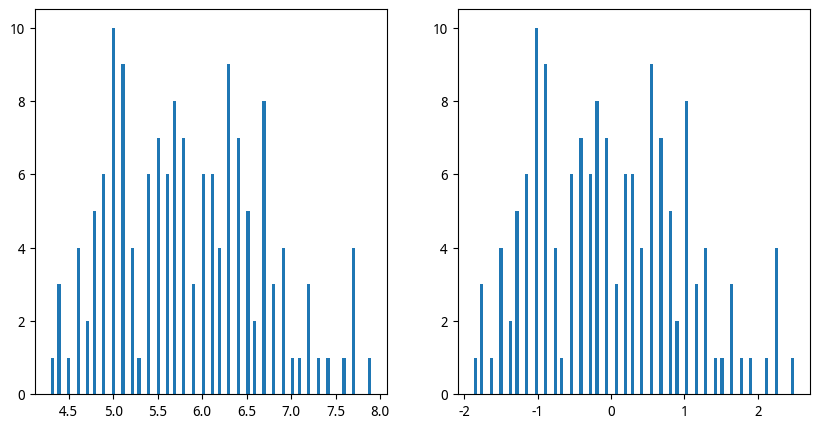

In [6]:
%matplotlib inline
from matplotlib import pyplot as plt
fig1=plt.figure(figsize=(10,5))
plt.subplot(121)
plt.hist(x.loc[:,'sepal_length_cm'],bins=100)

plt.subplot(122)
plt.hist(x_norm[:,0],bins=100)
plt.show()

In [7]:
print(x.shape)

(150, 4)


In [8]:
from sklearn.decomposition import PCA
pca=PCA(n_components=4)
x_pca_4=pca.fit_transform(x_norm)

var_ratio=pca.explained_variance_ratio_
print(var_ratio)

[0.72770452 0.23030523 0.03683832 0.00515193]


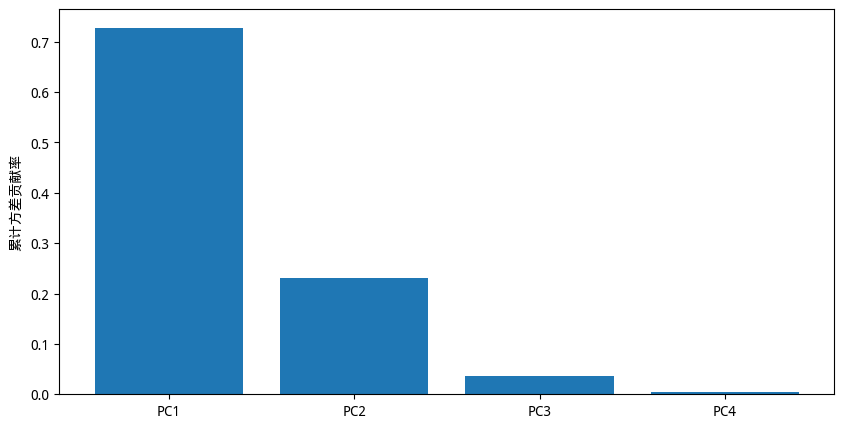

In [9]:
fig2=plt.figure(figsize=(10,5))
plt.bar([1,2,3,4],var_ratio)
plt.xticks([1,2,3,4],['PC1','PC2','PC3','PC4'])
plt.ylabel('累计方差贡献率')
plt.show()

In [10]:
pca=PCA(n_components=2)
x_pca_2=pca.fit_transform(x_norm)
x_pca_2.shape

(150, 2)

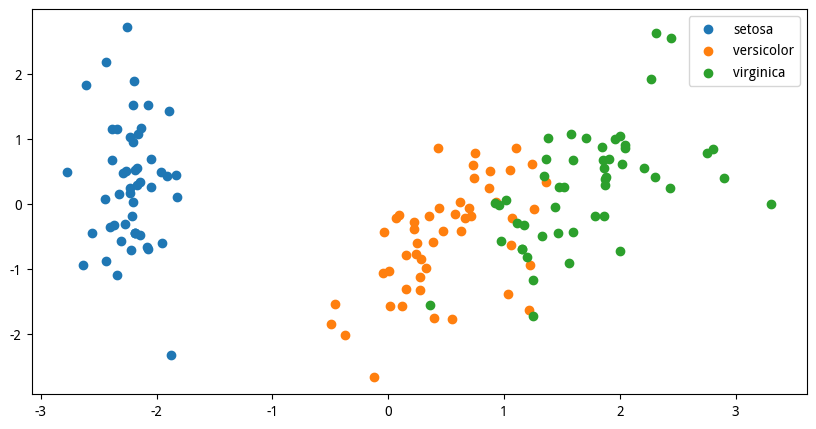

In [11]:
fig3=plt.figure(figsize=(10,5))
setosa=plt.scatter(x_pca_2[:,0][y==0],x_pca_2[:,1][y==0])
versicolor=plt.scatter(x_pca_2[:,0][y==1],x_pca_2[:,1][y==1])
virginica=plt.scatter(x_pca_2[:,0][y==2],x_pca_2[:,1][y==2])
plt.legend((setosa,versicolor,virginica),('setosa','versicolor','virginica'))
plt.show()

In [12]:
KNN_pca=KNeighborsClassifier(n_neighbors=3)
KNN_pca.fit(x_pca_2,y)
y_predict_pca=KNN_pca.predict(x_pca_2)
KNN_accuracy_pca=accuracy_score(y,y_predict_pca)
print(KNN_accuracy_pca)

0.9466666666666667
